# Data Processing

Specify Model class in [nba/models.py](nba/models.py) with the corresponding ```.yaml``` config. The build_model method in [nba/models.py](nba/models.py) loads the model from the config.

We can pass a model with it's config the following way:

In [20]:
from config.config import Config
from nba import NBATrainer, NBASubmission, NBAVisualizer

cfg = Config(path="config/heteroSTGCN.yaml").load()

trainer = NBATrainer(cfg)

## k-fold training/prediction

K-fold training method splits the training set into k partitions and always trains on k-1 partitions and validates/tests on the last partition, with early stopping. In the end we get the avg. test loss and a plot for validation and training losses over epochs in the folder ```saved_models/MODEL_NAME``` (MODEL_NAME specified in .yaml).

The best modelcheckpoint over the folds is saved in the same folder such that we can then run the visualization metrics (but for the submission we then want to train on all the training data we have).

  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
Fold 0 | Test Loss: 0.0337
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
Fold 1 | Test Loss: 0.0355
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 2 of 5
Fold 2 | Test Loss: 0.0350
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 2 of 5
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 2 of 5
Fold 3 | Test Loss: 0.0343
Logs saved to saved_models/HeteroSTGCN/kfold_results.json


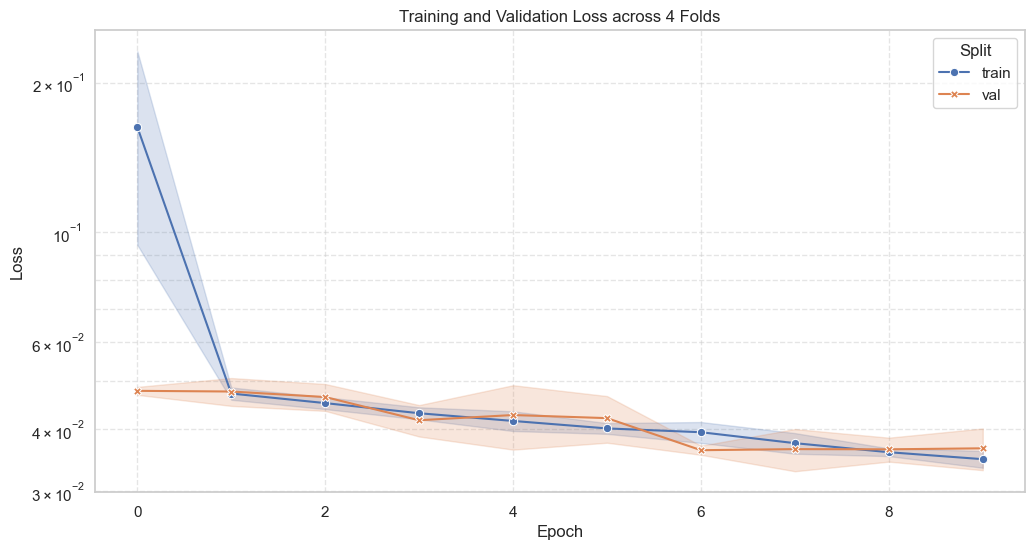

Training stats plot saved to saved_models/HeteroSTGCN/kfold_plot.png
Training finished
Avg. test loss over folds: 0.03460847837850452


In [ ]:
trainer.train_k_fold(k=4)

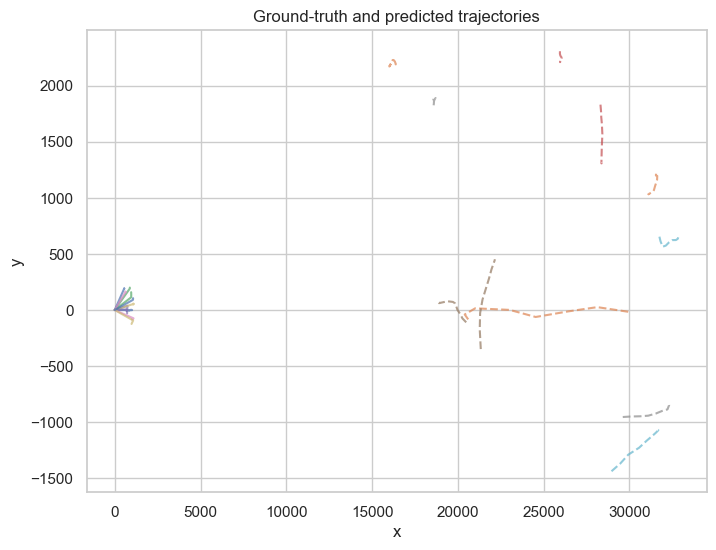

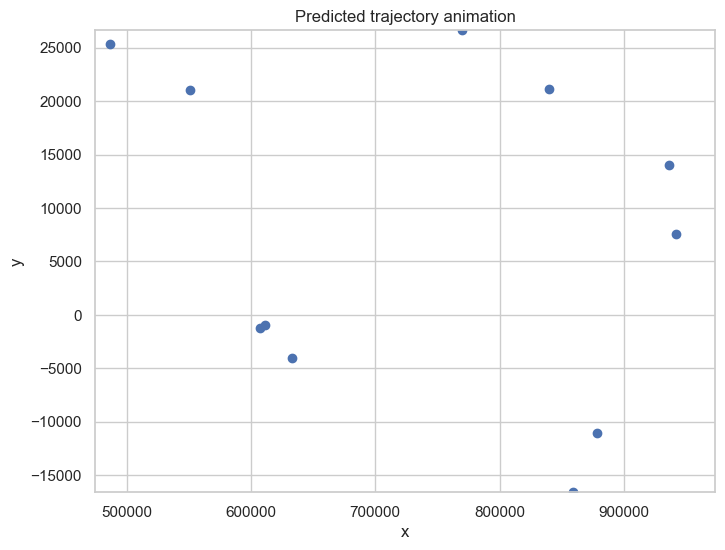

In [23]:
viz = NBAVisualizer(cfg, trainer)
viz.plot_example()
viz.animate_example()

##### k-fold example for another training architecture

In [24]:
cfg = Config(path="config/gan_gru.yaml").load()
trainer = NBATrainer(cfg)

  [EarlyStopping] Counter 1 of 5
Fold 0 | Test Loss: 0.0563
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
Fold 1 | Test Loss: 0.0528
Logs saved to saved_models/GAN_GRU/kfold_results.json


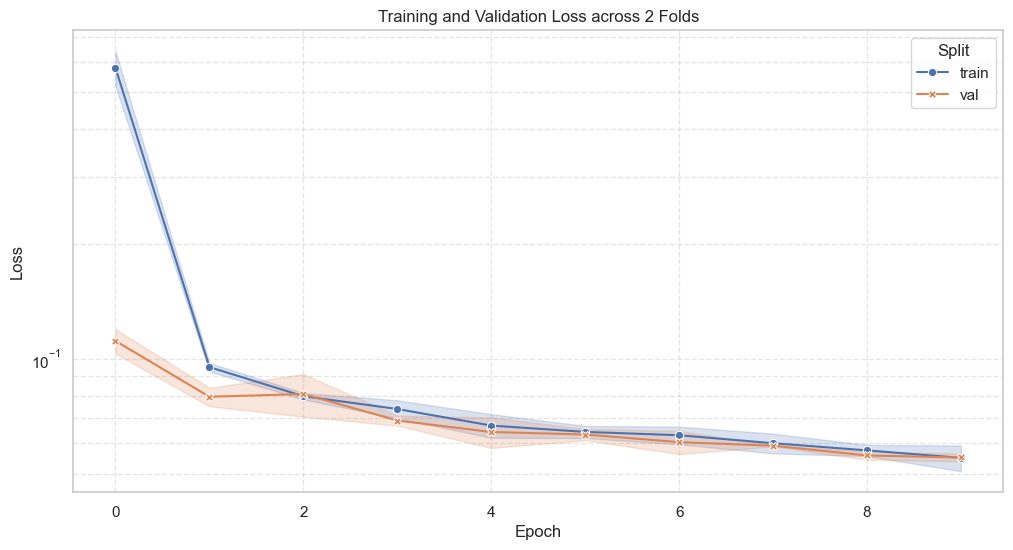

Training stats plot saved to saved_models/GAN_GRU/kfold_plot.png
Training finished
Avg. test loss over folds: 0.05457616532221436


In [25]:
trainer.train_k_fold(k=2)

## train on all the data

To train on all the training data we have, we can just run the train method on the traininer (which then overrides the checkpoint.pth from the k-fold), therefore the visualizations and predictions are then on this checkpoint. Here, no early stopping is implemented, so we'd have to adjust the config. 

In [ ]:
cfg = Config(path="config/heteroSTGCN.yaml").load()
trainer = NBATrainer(cfg)

trainer.train()
sub = NBASubmission(cfg, trainer)
sub.create()